Analyze time-series fluorescence data from PURE (Protein synthesis Using Recombinant Elements) experiments. 

## Setup 

In [1]:
!pip install nucleus-cdk==0.5.0rc2 | tail -n2

# Surface a failed install here, rather than as a confusing ModuleNotFoundError
# in the import cell below.
import importlib.metadata as md
assert md.version("nucleus-cdk") == "0.5.0rc2", f"got {md.version('nucleus-cdk')}"

In [2]:
%load_ext autoreload
%autoreload 2
    
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Import the cdk platereader module
from cdk.analysis.cytosol import platereader as pr

# Set up plotting
pr.plot_setup()

## Load Data

In [3]:
# Specify file paths
data_file = "20251211-110513-cytation5-pure-timecourse-gfp--biotek-cdk.txt"
platemap_file = "20251211-ClpXP-Cy5.csv"


# Load data
data, platemap = pr.load_platereader_data(
    data_file=data_file,
    platemap_file=platemap_file,
    platereader="biotek-cdk"  # Options: "cytation", "envision", "biotek-cdk"
)

# Checkout first few rows
data.head()

,Time,Well,Data,Row,Column,Read,Plate,Clock Time,Experiment,Name,CP
0,0 days 00:00:05,G1,319,G,1,GFP-Gext,Plate 1,2025-12-11 11:05:18,ClpXP,2.1 ng/ul ClpX DNA + Purified 2.1 uM ClpP prot...,1
1,0 days 00:05:05,G1,309,G,1,GFP-Gext,Plate 1,2025-12-11 11:10:18,ClpXP,2.1 ng/ul ClpX DNA + Purified 2.1 uM ClpP prot...,1
2,0 days 00:10:05,G1,490,G,1,GFP-Gext,Plate 1,2025-12-11 11:15:18,ClpXP,2.1 ng/ul ClpX DNA + Purified 2.1 uM ClpP prot...,1
3,0 days 00:15:05,G1,1446,G,1,GFP-Gext,Plate 1,2025-12-11 11:20:18,ClpXP,2.1 ng/ul ClpX DNA + Purified 2.1 uM ClpP prot...,1
4,0 days 00:20:05,G1,3015,G,1,GFP-Gext,Plate 1,2025-12-11 11:25:18,ClpXP,2.1 ng/ul ClpX DNA + Purified 2.1 uM ClpP prot...,1


## Plot Raw Curves

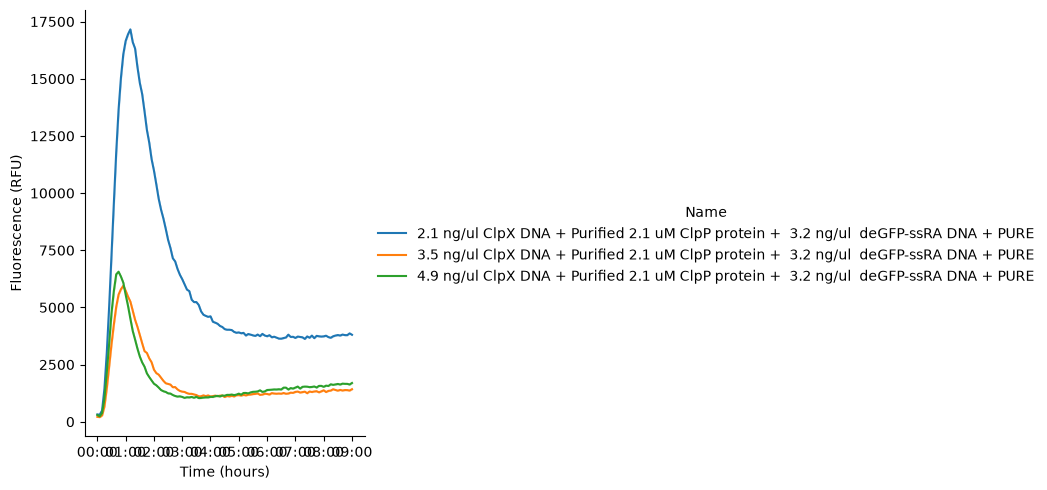

In [4]:
g = pr.plot_curves(data=data)

## Normalize Data

In [5]:
# No HPTS/fluorescein control was run on this plate - `ctrl_name='10 uM HPTS'`
# matched zero wells, so this call raised. The published sibling notebook
# (Cytation 3) has no normalization step either, so we use the raw data.
# data = pr.normalize_data_to_controls(data, ctrl_name = '10 uM HPTS')


Now replot your curves to see them normalized

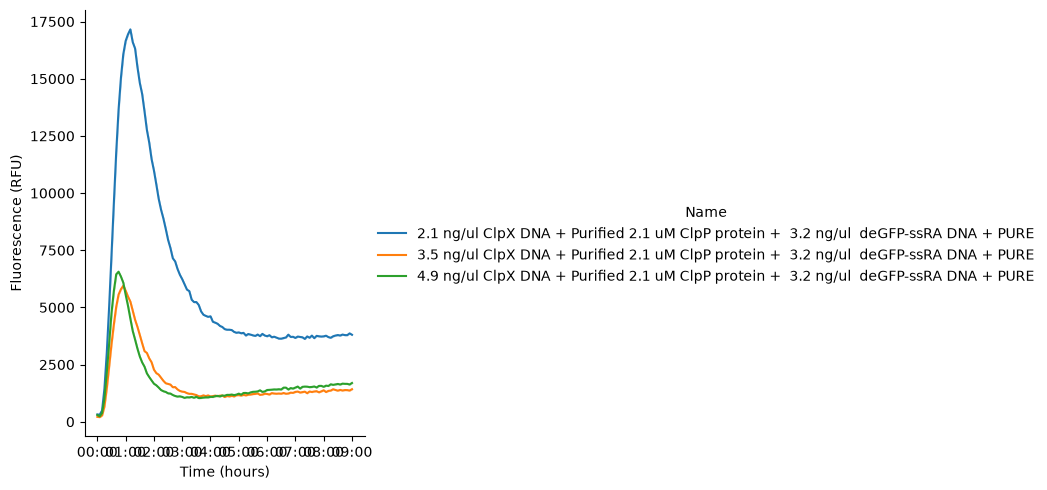

In [6]:
g = pr.plot_curves(data=data)

## Kinetic Analysis
**Metrics extracted:**

  - **Vmax** (`Velocity Max`): Maximum rate of fluorescence increase (slope at inflection point)
  - **Lag time**: Time to reach the exponential phase
  - **Steady-state**: Final fluorescence level and time to reach 95% of asymptote
  - **Drift**: Rate of signal decay or increase after steady-state
  - **R²**: Goodness of fit

In [7]:
# Perform kinetic analysis using sigmoid_drift model
kinetics = pr.kinetic_analysis(
    data=data,
    group_by=['Name'],  # Group by experimental condition
)

kinetics.head()

PROVIDING AVERAGED KINETICS


Velocity  \
                                                                        Time   
Name                                                                           
2.1 ng/ul ClpX DNA + Purified 2.1 uM ClpP prote... 0 days 00:26:49.447681274   
3.5 ng/ul ClpX DNA + Purified 2.1 uM ClpP prote... 0 days 00:24:50.185588867   
4.9 ng/ul ClpX DNA + Purified 2.1 uM ClpP prote... 0 days 00:23:09.170942208   

                                                                      \
                                                      Data       Max   
Name                                                                   
2.1 ng/ul ClpX DNA + Purified 2.1 uM ClpP prote... 6048.15  39979.11   
3.5 ng/ul ClpX DNA + Purified 2.1 uM ClpP prote... 1401.97 136854.89   
4.9 ng/ul ClpX DNA + Purified 2.1 uM ClpP prote... 1126.45 264469.31   

                                                                         Lag  \
                                                                        Time   
Name                                                                           
2.1 ng/ul ClpX DNA + Purified 2.1 uM ClpP prote... 0 days 00:17:44.829556760   
3.5 ng/ul ClpX DNA + Purified 2.1 uM ClpP prote... 0 days 00:24:13.306506901   
4.9 ng/ul ClpX DNA + Purified 2.1 uM ClpP prote... 0 days 00:22:53.837538355   

                                                            \
                                                      Data   
Name                                                         
2.1 ng/ul ClpX DNA + Purified 2.1 uM ClpP prote... 1625.42   
3.5 ng/ul ClpX DNA + Purified 2.1 uM ClpP prote...  821.30   
4.9 ng/ul ClpX DNA + Purified 2.1 uM ClpP prote... 1025.75   

                                                                Steady State  \
                                                                        Time   
Name                                                                           
2.1 ng/ul ClpX DNA + Purified 2.1 uM ClpP prote... 0 days 00:40:11.245098162   
3.5 ng/ul ClpX DNA + Purified 2.1 uM ClpP prote... 0 days 00:25:44.479690820   
4.9 ng/ul ClpX DNA + Purified 2.1 uM ClpP prote... 0 days 00:23:31.745077897   

                                                             \
                                                       Data   
Name                                                          
2.1 ng/ul ClpX DNA + Purified 2.1 uM ClpP prote... 11491.49   
3.5 ng/ul ClpX DNA + Purified 2.1 uM ClpP prote...  2663.74   
4.9 ng/ul ClpX DNA + Purified 2.1 uM ClpP prote...  2140.25   

                                                                                                  Fit  \
                                                                                               params   
Name                                                                                                    
2.1 ng/ul ClpX DNA + Purified 2.1 uM ClpP prote...  [12096.304486005622, 13.220272479969234, 0.447...   
3.5 ng/ul ClpX DNA + Purified 2.1 uM ClpP prote...  [2803.9346714742605, 195.2326301318854, 0.4139...   
4.9 ng/ul ClpX DNA + Purified 2.1 uM ClpP prote...  [2252.897070261338, 469.5630641591759, 0.38588...   

                                                                  
                                                    R^2    drift  
Name                                                              
2.1 ng/ul ClpX DNA + Purified 2.1 uM ClpP prote... 0.66 -1325.98  
3.5 ng/ul ClpX DNA + Purified 2.1 uM ClpP prote... 0.45  -332.60  
4.9 ng/ul ClpX DNA + Purified 2.1 uM ClpP prote... 0.28  -266.19

## Visualize Fits on Individual Wells

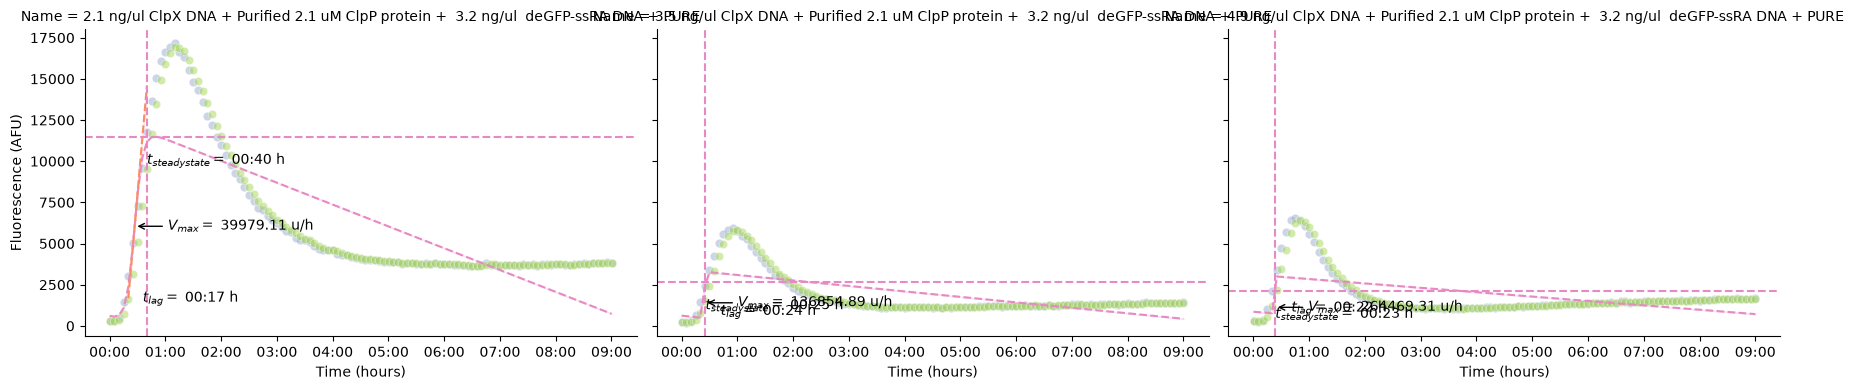

In [8]:
# Plot kinetic fits 
g, kinetics = pr.plot_kinetics(data, kinetics=kinetics, group_by=["Name"])

## Summary Plots

/private/tmp/claude-501/-Users-jon-src-nucleus-eng-2026-CERN-OHL-P/cb8c8656-1a50-4a3f-aa15-244096ea0585/scratchpad/venv05/lib/python3.14/site-packages/cdk/analysis/cytosol/platereader.py:1588: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


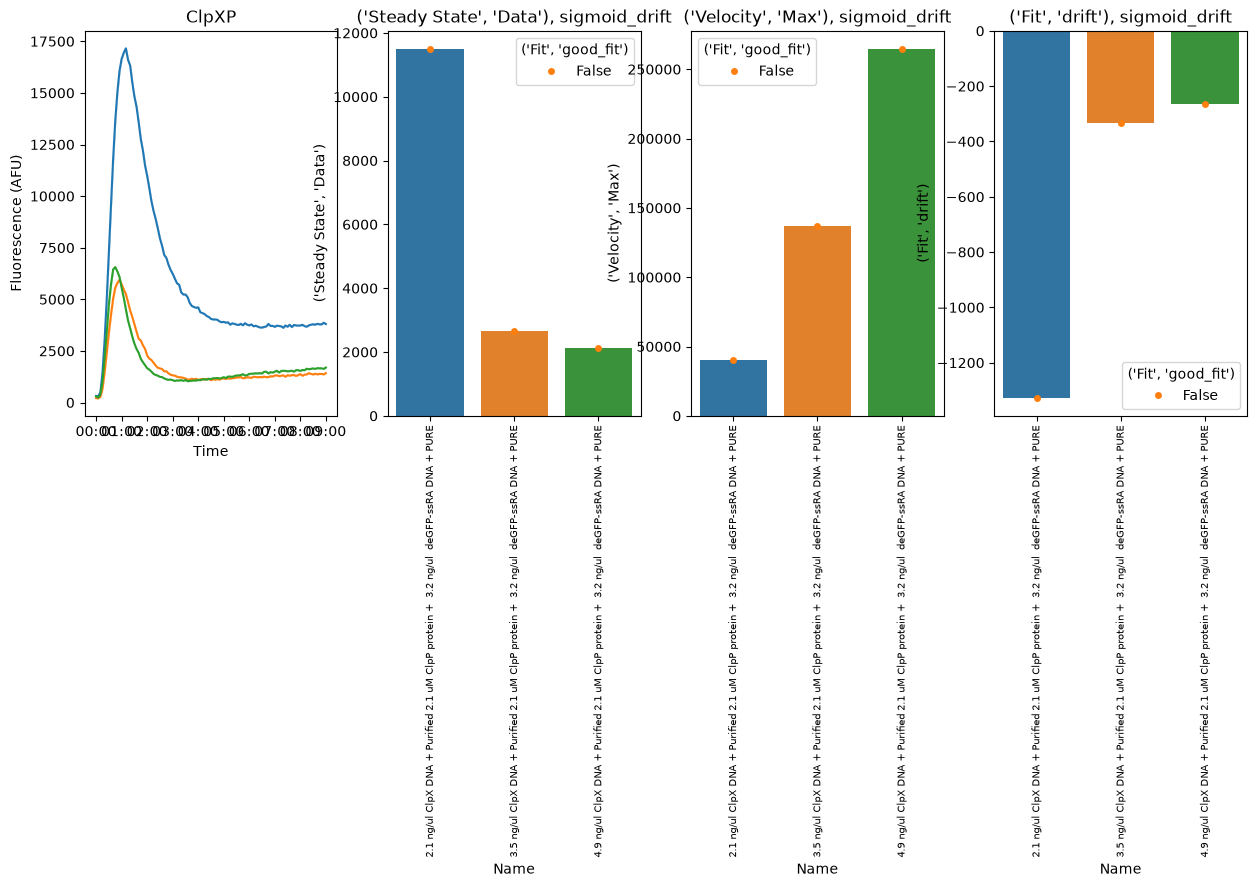

In [9]:
pr.plot_summary(data)

---

## Key Metrics Explained

### 1. **Steady-State Level** (`Steady State, Data`)
- The final fluorescence value reached by the reaction
- Represents the total amount of protein produced
- Higher values indicate greater expression yield

### 2. **Maximum Velocity** (`Velocity, Max`)
- The steepest slope of the fluorescence curve (at the inflection point)
- Units: RFU per second
- Reflects the peak rate of protein synthesis
- Sensitive to enzyme activity, substrate availability, and reaction conditions

### 3. **Lag Time** (`Lag, Time`)
- Time before exponential fluorescence increase begins
- May reflect time for ribosome assembly or initial translation steps
- Shorter lag times suggest faster reaction initiation

### 4. **Drift** (`Fit, drift`)
- Rate of fluorescence change after reaching steady-state
- Positive drift: continued synthesis or aggregation
- Negative drift: photobleaching, protein degradation, or quenching
- Units: RFU per second

### 5. **R² Value** (`Fit, R^2`)
- Goodness of fit (0 to 1, higher is better)
- R² > 0.98 indicates excellent fit
- Poor fits may indicate noisy data, overflow errors, or non-sigmoid kinetics

---

## Tips and Troubleshooting

- **Overflow errors:** Wells with `OVRFLW` or `NaN` values are automatically excluded from fitting
- **Poor fits (low R²):** Inspect raw curves for anomalies (bubbles, evaporation, pipetting errors)
- **Drift:** Sometimes seen in kinetics curves; use `sigmoid_drift` model
- **Multiple replicates:** Always include technical replicates and report error bars
- **Comparing conditions:** Normalize or blank data consistently across all samples

---

## Next Steps

- Export kinetics results: `pr.export_kinetics(kinetics, 'results.csv')`
- Statistical analysis: Use `scipy.stats` or `statsmodels` for ANOVA/t-tests
- Parameter optimization: Vary Mg²⁺, K⁺, or other conditions to maximize Vmax or steady-state
- Mechanistic modeling: Fit ODE models to extract biological rate constants